In [67]:
from collections import defaultdict
import pandas as pd
from pandas import DataFrame
import numpy as np

### global settings
dsname_2_ds = {
    "sharegpt": "sharegpt_offline",
    "burstgpt": "burstgpt_offline",
    # "gov_report": "longbench--gov_report_offline",
    "narrativeqa": "longbench--narrativeqa_offline",
    # "vcsum": "longbench--vcsum_offline",
    # "dureader": "longbench--dureader_offline",
    "codeU": "leval--codeU_offline",
}

ds2genlenandreqspair = {
    "sharegpt_offline": (-1, 5000),
    "burstgpt_offline": (-1, 5000),
    "longbench--narrativeqa_offline": (128, 200),
    "leval--codeU_offline": (512, 90),
}


strategies = {
    "default": "default",
    "evict-optimal-7": "opt7",
}

global_strategies_mapping = {
    "default": "default",
    "opt7": "evict-optimal-7",
}

local_strategies_mapping = {
    "vLLM-default": "default",
    "Our-approach": "opt7",
}

strategies_mapping_labels = {
    "default": "vLLM-default",
    "evict-optimal-7": "Our-approach"
}

repeats=3

def parse_log_and_extract_performance_metrics(log_file_path):
    """
    Parse the log file and extract performance metrics.
    
    Args:
        log_file_path (str): The path to the log file.
        
    Returns:
        dict: A dictionary containing the performance metrics.
    """
    import os
    
    # Check if file exists
    if not os.path.exists(log_file_path):
        print(f"Warning: Log file not found: {log_file_path}")
        return None
    
    performance_metrics = {}
    
    try:
        with open(log_file_path, 'r') as file:
            for line in file:
                line = line.strip()
                if 'Elapsed time:' in line:
                    try:
                        performance_metrics['e2e_elapsed_time_s'] = float(line.split()[2])
                    except (IndexError, ValueError) as e:
                        print(f"Warning: Could not parse elapsed time from line: {line}")
                elif 'Num requests:' in line:
                    try:
                        performance_metrics['num_requests'] = int(line.split()[-1])
                    except (IndexError, ValueError) as e:
                        print(f"Warning: Could not parse num requests from line: {line}")
                elif 'Throughput:' in line:
                    try:
                        performance_metrics['throughput_reqs_per_s'] = float(line.split()[1])
                        performance_metrics['throughput_tok_per_s'] = float(line.split()[3])
                    except (IndexError, ValueError) as e:
                        print(f"Warning: Could not parse throughput from line: {line}")
                elif 'Total num tokens:' in line:
                    try:
                        performance_metrics['total_tokens'] = int(line.split()[-1])
                    except (IndexError, ValueError) as e:
                        print(f"Warning: Could not parse total tokens from line: {line}")
    
    except Exception as e:
        print(f"Error reading file {log_file_path}: {e}")
        return None
    
    # Check if we got any metrics
    if not performance_metrics:
        print(f"Warning: No performance metrics found in {log_file_path}")
        return None
    
    return performance_metrics

def convert_datasetmetrics_to_df(dataset_metics):
    ## flatten all runs
    rows = []
    for chunked_size, run_metrics in dataset_metics.items():
        if isinstance(run_metrics, dict):
            run_metrics = [run_metrics]
            
        for i, metrics in enumerate(run_metrics):
            rows.append({'chunked_size': chunked_size, **metrics})

    df_runs = pd.DataFrame(rows)

    # Average across runs (numeric columns only)
    metric_cols = (
        df_runs.select_dtypes(include=np.number)
               .columns.difference(['run', 'chunked_size'])
    )

    df_avg = (
        df_runs
        .groupby(['chunked_size'], as_index=False)[metric_cols]
        .mean()
    )

    return df_avg


def get_throughput_log_file_path(base_dir, strategy, dataset, model_name, chunked_size, context_len, tp, try_idx):
    if dataset not in ds2genlenandreqspair:
        genlen, reqs = 512, 200 # default
    else:
        genlen, reqs = ds2genlenandreqspair[dataset]

    if genlen == -1:
        log_file_path = f"{base_dir}/{strategy}/logs_v1_{model_name}_ofd0/{dataset}/offline_c{context_len}_r{reqs}_tp{tp}_pp1_gpu0.9_bt{chunked_size}_{try_idx}_.log"
    else:
        log_file_path = f"{base_dir}/{strategy}/logs_v1_{model_name}_ofd0/{dataset}/offline_c{context_len}_g{genlen}_r{reqs}_tp{tp}_pp1_gpu0.9_bt{chunked_size}_{try_idx}_.log"

    return log_file_path

def get_stats_csv_file_path(base_dir, strategy, dataset, model_name, chunked_size, context_len, tp, try_idx, stats_type):
    assert stats_type in ["reqs_stats", "sched_stats"], f"stats_type must be one of ['reqs_stats', 'sched_stats'], but got {stats_type}"
    
    if dataset not in ds2genlenandreqspair:
        genlen, reqs = 512, 200 # default
    else:
        genlen, reqs = ds2genlenandreqspair[dataset]

    if stats_type == "reqs_stats":
        csv_file_path = f"{base_dir}/{strategy}/logs_v1_{model_name}_ofd0/{dataset}/{strategies[strategy]}_c{context_len}_g{genlen}_r{reqs}_gp0.9_bt{chunked_size}_{try_idx}_req_stats.csv"
    elif stats_type == "sched_stats":
        csv_file_path = f"{base_dir}/{strategy}/logs_v1_{model_name}_ofd0/{dataset}/{strategies[strategy]}_c{context_len}_g{genlen}_r{reqs}_gp0.9_bt{chunked_size}_{try_idx}_sched_stats.csv"

    return csv_file_path
        
        

def get_throughput_df(base_dir, strategy, dataset, model_name, chunked_sizes, tp):
    # Simplified structure: dataset_metics[chunked_size] = [list of metrics from multiple runs]
    dataset_metics = defaultdict(list)
    ### only for llama-3.1-8B
    if tp == 4 and "Yi-Coder-9B-Chat-8x-MoE" in model_name:
        context_len = 131072
    else:
        context_len = 32768
    
    for try_idx in range(1, repeats + 1):
        for chunked_size in chunked_sizes:
            log_file_path = get_throughput_log_file_path(base_dir, strategy, dataset, model_name, chunked_size, context_len, tp, try_idx)
            peformance_metrics = parse_log_and_extract_performance_metrics(log_file_path)
            
            # print(f"chunk_size: {chunked_size} peformance_metrics: {peformance_metrics}")
            # Only append if we got valid metrics
            if peformance_metrics is not None:
                dataset_metics[chunked_size].append(peformance_metrics)
            else:
                print(f"Skipping {log_file_path} due to parsing error")

    df = convert_datasetmetrics_to_df(dataset_metics)

    return df


def get_avg_latency_df(base_dir, strategy, dataset, model_name, chunked_sizes, tp):
    ### only for llama-3.1-8B
    if tp == 4 and "Yi-Coder-9B-Chat-8x-MoE" in model_name:
        context_len = 131072
    else:
        context_len = 32768

    rows = []
    
    for chunked_size in chunked_sizes:
        avg_latency_lists = defaultdict(list)
        for try_idx in range(1, repeats + 1):
            reqs_csv_file_path = get_stats_csv_file_path(base_dir, strategy, dataset, model_name, chunked_size, context_len, tp, try_idx, "reqs_stats")
            df = pd.read_csv(reqs_csv_file_path)
            avg_latency_lists["e2e_latency_ms"].append(df["e2e_latency_ms"].mean())
            avg_latency_lists["queued_time_ms"].append(df["queued_time_ms"].mean())
            avg_latency_lists["prefill_time_ms"].append(df["prefill_time_ms"].mean())
            avg_latency_lists["decode_time_ms"].append(df["decode_time_ms"].mean())
            avg_latency_lists["inference_time_ms"].append(df["inference_time_ms"].mean())
            avg_latency_lists["ttft_latency_ms"].append(df["ttft_latency_ms"].mean())
            avg_latency_lists["ttft_latency_ms_p90"].append(df["ttft_latency_ms"].quantile(0.9))
            avg_latency_lists["ttft_latency_ms_p95"].append(df["ttft_latency_ms"].quantile(0.95))
            avg_latency_lists["ttft_latency_ms_p99"].append(df["ttft_latency_ms"].quantile(0.99))
            avg_latency_lists["tpot_latency_ms"].append(df["tpot_latency_ms"].mean())
            avg_latency_lists["tpot_latency_ms_p90"].append(df["tpot_latency_ms"].quantile(0.9))
            avg_latency_lists["tpot_latency_ms_p95"].append(df["tpot_latency_ms"].quantile(0.95))
            avg_latency_lists["tpot_latency_ms_p99"].append(df["tpot_latency_ms"].quantile(0.99))

        row = {
            "chunked_size": chunked_size,
            "e2e_latency_ms": sum(avg_latency_lists["e2e_latency_ms"]) / len(avg_latency_lists["e2e_latency_ms"]),
            "queued_time_ms": sum(avg_latency_lists["queued_time_ms"]) / len(avg_latency_lists["queued_time_ms"]),
            "prefill_time_ms": sum(avg_latency_lists["prefill_time_ms"]) / len(avg_latency_lists["prefill_time_ms"]),
            "decode_time_ms": sum(avg_latency_lists["decode_time_ms"]) / len(avg_latency_lists["decode_time_ms"]),
            "inference_time_ms": sum(avg_latency_lists["inference_time_ms"]) / len(avg_latency_lists["inference_time_ms"]),
            "ttft_latency_ms": sum(avg_latency_lists["ttft_latency_ms"]) / len(avg_latency_lists["ttft_latency_ms"]),
            "ttft_latency_ms_p90": sum(avg_latency_lists["ttft_latency_ms_p90"]) / len(avg_latency_lists["ttft_latency_ms_p90"]),
            "ttft_latency_ms_p95": sum(avg_latency_lists["ttft_latency_ms_p95"]) / len(avg_latency_lists["ttft_latency_ms_p95"]),
            "ttft_latency_ms_p99": sum(avg_latency_lists["ttft_latency_ms_p99"]) / len(avg_latency_lists["ttft_latency_ms_p99"]),
            "tpot_latency_ms": sum(avg_latency_lists["tpot_latency_ms"]) / len(avg_latency_lists["tpot_latency_ms"]),
            "tpot_latency_ms_p90": sum(avg_latency_lists["tpot_latency_ms_p90"]) / len(avg_latency_lists["tpot_latency_ms_p90"]),
            "tpot_latency_ms_p95": sum(avg_latency_lists["tpot_latency_ms_p95"]) / len(avg_latency_lists["tpot_latency_ms_p95"]),
            "tpot_latency_ms_p99": sum(avg_latency_lists["tpot_latency_ms_p99"]) / len(avg_latency_lists["tpot_latency_ms_p99"]),
        }
        rows.append(row)

    return pd.DataFrame(rows)

#### Read the scheduling statistics csv file
def get_sched_stats_df(base_dir, strategy, model_name, dataset, chunked_size, tp):
    ### only for llama-3.1-8B
    if tp == 4 and "Yi-Coder-9B-Chat-8x-MoE" in model_name:
        context_len = 131072
    else:
        context_len = 32768

    strategy = local_strategies_mapping[strategy]
    strategy = global_strategies_mapping[strategy]
    dataset_name = dsname_2_ds[dataset]
    ### construct the csv path
    sched_csv_file_path = get_stats_csv_file_path(base_dir, strategy, dataset_name, model_name, chunked_size, context_len, tp, 1, "sched_stats")
    # Read the scheduling statistics CSV
    sched_df = pd.read_csv(sched_csv_file_path)
    
    # Extract the necessary columns
    if 'total_scheduled_tokens' not in sched_df.columns or 'total_preempted_tokens' not in sched_df.columns:
        raise ValueError("CSV must contain 'total_scheduled_tokens' and 'total_preempted_tokens' columns")
    
    if 'per_step_dur_ms' not in sched_df.columns:
        raise ValueError("CSV must contain 'per_step_dur_ms' column")
    
    sched_df['cumulative_time_s'] = sched_df['per_step_dur_ms'].cumsum() / 1000.0
    
    return sched_df

#### Get recomputation requests and tokens
def get_recomputations_df(base_dir, strategy, dataset, model_name, chunked_sizes, tp):
    ### only for llama-3.1-8B
    if tp == 4 and "Yi-Coder-9B-Chat-8x-MoE" in model_name:
        context_len = 131072
    else:
        context_len = 32768

    rows = []
    
    for chunked_size in chunked_sizes:
        total_reqs_per_run = []
        total_tokens_per_run = []
        for try_idx in range(1, repeats + 1):
            sched_csv_file_path = get_stats_csv_file_path(base_dir, strategy, dataset, model_name, chunked_size, context_len, tp, try_idx, "sched_stats")
            df = pd.read_csv(sched_csv_file_path)

            # Sum recomputation events per run (across steps)
            if "num_preempted_requests" in df.columns:
                total_reqs = pd.to_numeric(df["num_preempted_requests"], errors="coerce").fillna(0).sum()
            else:
                total_reqs = 0

            if "total_preempted_tokens" in df.columns:
                total_tokens = pd.to_numeric(df["total_preempted_tokens"], errors="coerce").fillna(0).sum()
            else:
                total_tokens = 0

            total_reqs_per_run.append(total_reqs)
            total_tokens_per_run.append(total_tokens)

        # Average totals across runs and also report overall totals across runs
        row = {
            "chunked_size": chunked_size,
            "avg_recmp_reqs": float(np.mean(total_reqs_per_run)) if total_reqs_per_run else 0.0,
            "avg_recmp_tokens": float(np.mean(total_tokens_per_run)) if total_tokens_per_run else 0.0,
        }
        rows.append(row)

    return pd.DataFrame(rows)


In [68]:
def get_dataset(output_df, base_dir, dataset_name, model_name, strategy, category, chunked_sizes, tp):
    assert category in ["throughput", "latency", "recmp"]
    strategy = local_strategies_mapping[strategy]

    assert strategy in global_strategies_mapping and dataset_name in dsname_2_ds

    if category == "throughput":
        df_thrpt = get_throughput_df(base_dir, global_strategies_mapping[strategy], dsname_2_ds[dataset_name], model_name, chunked_sizes, tp)
        output_df[global_strategies_mapping[strategy]][dataset_name] = df_thrpt

    elif category == "latency":
        df_latency = get_avg_latency_df(base_dir, global_strategies_mapping[strategy], dsname_2_ds[dataset_name], model_name, chunked_sizes, tp)
        output_df[global_strategies_mapping[strategy]][dataset_name] = df_latency

    elif category == "recmp":
        df_recmp = get_recomputations_df(base_dir, global_strategies_mapping[strategy], dsname_2_ds[dataset_name], model_name, chunked_sizes, tp)
        output_df[global_strategies_mapping[strategy]][dataset_name] = df_recmp

    return output_df


In [69]:
#### global settings for all plots
from matplotlib import hatch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.weight': 'normal'})

densely_dashdotted = (0, (3, 1, 1, 1))
long_dash_with_offset = (5, (10, 3))
line_styles = ['solid', 'dashed', 'dashdot', densely_dashdotted, long_dash_with_offset, 'dotted']
hatches = ['o', '\\\\', 'x', 'O', 'x', '\\', '--', 'o']
markers = ['s', "^", 'd', 'P', 'X']

orig_colors = sns.color_palette("colorblind")
bar_colors = [
    orig_colors[9],
    orig_colors[8],
    orig_colors[7],
    # orig_colors[1],
    # orig_colors[4],
    # orig_colors[2],
]
line_colors = [
    "blue",
    orig_colors[4],
    orig_colors[2],
    # orig_colors[9],
    # "lightpurple",
    # "lightolive",
]

#### Plot chunked-prefill length vs. throughput and recompute tokens for different datasets
def plot_thrpt_and_recmp_vs_ckprefilllen(chunked_prefill_lens, my_df_throughput, my_df_recmp, saved_file):
    # Categorical x-axis
    x_vals = list(chunked_prefill_lens)
    x_labels = [f"{int(x/1024)}K" if x >= 1024 else str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per dataset
    num_datasets = len(my_df_throughput.keys())
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_datasets)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_datasets)]
    bar_width = bar_width * (1 - 0.05)

    plt.rcParams['hatch.color'] = 'black'
    fig, ax = plt.subplots(figsize=(5, 2))
    ax2 = ax.twinx()

    bar_handles = []
    line_handles = []
    all_bar_heights = []

    for i, dataset_name in enumerate(my_df_throughput.keys()):
        # Throughput as bars (left y)
        df_t = my_df_throughput[dataset_name]
        if isinstance(df_t, pd.DataFrame) and not df_t.empty:
            df_t = df_t.sort_values("chunked_size")
            t_map = df_t.set_index("chunked_size")["throughput_tok_per_s"]
            heights = [t_map.get(v, float("nan")) for v in x_vals]
            
            # Normalize to the baseline (smallest chunk size)
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=bar_colors[i], hatch=hatches[i], alpha=1, label=f"{dataset_name}(left-y)")
            all_bar_heights.extend([v for v in heights if np.isfinite(v)])
            bar_handles.append(h)

        # Recomputed tokens as lines (right y)
        df_right_y = my_df_recmp[dataset_name]
        if isinstance(df_right_y, pd.DataFrame) and not df_right_y.empty:
            df_right_y = df_right_y.sort_values("chunked_size")
            right_y_map = df_right_y.set_index("chunked_size")["avg_recmp_tokens"]
            label = f"{dataset_name}(right-y)"
            y_line = [right_y_map.get(v, float("nan")) for v in x_vals]
            
            if markers[i] == 's' or markers[i] == 'o':
                markersize = 6
            else:
                markersize = 8

            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                linestyle=line_styles[i],
                marker=markers[i],
                markersize=markersize,
                linewidth=2,
                color=line_colors[i],
                label=f"{label}",
            )
            line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Chunk Size (tokens)", fontsize=14, fontweight="bold")
    for tick in ax.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.set_ylabel("Throughput (tokens/s)", fontsize=14, fontweight="bold")
    if all_bar_heights:
        top = max(all_bar_heights)
        ax.set_ylim(bottom=0, top=top * 1.08)
    else:
        ax.set_ylim(bottom=0)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1000:.1f}k' if x >= 1000 else f'{x:.1f}')
    )
    
    
    for tick in ax2.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    # ax2.tick_params(axis='y', colors='blue')
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p:
            f"{int(x/1_000_000)}M" if x >= 1_000_000 else
            (f"{int(x/1_000)}k" if x >= 1_000 else f"{int(x)}")
        )
    )
    ax2.set_ylabel("Num. of Recmp Tokens", fontsize=14, fontweight="bold")
    # ax2.spines['right'].set_color('blue')
    ax2.set_ylim(bottom=0)
    
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels, fontsize=14, fontweight="bold")

    # Separate legends: bars (row 1) and lines (row 2)
    bar_labels = [h.get_label() for h in bar_handles]
    line_labels = [l.get_label() for l in line_handles]

    leg = fig.legend(
        bar_handles + line_handles,
        bar_labels + line_labels,
        loc='upper center',
        # bbox_to_anchor=(0.505, 1.11),
        bbox_to_anchor=(0.505, 1.22),
        ncol=2,
        columnspacing=0.5,      # reduce space between columns
        handletextpad=0.4,      # space between handle and text (optional)
        handlelength=2,       # handle length (optional)
        fancybox=True,
        shadow=False,
        borderaxespad=0.1,
        fontsize=12,
        prop={'weight': 'bold'},
    )

    # add borders to the bar entries (assumes bars come first)
    for patch in leg.get_patches()[:len(bar_handles)]:
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    if saved_file:
        # fig.savefig(saved_file, dpi=300, bbox_inches='tight')
        plt.savefig(f"{saved_file}.eps", format='eps', bbox_inches='tight')
        plt.savefig(f"{saved_file}.png", format='png', bbox_inches='tight')

    # fig.tight_layout()
    plt.show()


#### Plot chunked-prefill length vs. TTFT and Time between tokens latency for different datasets
def plot_latency_vs_ckprefilllen_noqueue(chunked_prefill_lens, my_df_latency, percentile=None, saved_file=None):
    # Categorical x-axis
    x_vals = list(chunked_prefill_lens)
    x_labels = [f"{int(x/1024)}K" if x >= 1024 else str(x) for x in x_vals]
    x_pos = {v: i for i, v in enumerate(x_vals)}

    # Bar positioning per dataset
    num_datasets = len(my_df_latency.keys())
    bar_group_width = 0.8
    bar_width = bar_group_width / max(1, num_datasets)
    offsets = [(-bar_group_width / 2) + (i + 0.5) * bar_width for i in range(num_datasets)]
    bar_width = bar_width * (1 - 0.05)

    plt.rcParams['hatch.color'] = 'black'
    fig, ax = plt.subplots(figsize=(5, 2))
    ax2 = ax.twinx()

    bar_handles = []
    line_handles = []
    all_bar_heights = []

    for i, dataset_name in enumerate(my_df_latency.keys()):
        # TTFT (only prefill time) latency as bars (left y)
        df_t = my_df_latency[dataset_name]
        if isinstance(df_t, pd.DataFrame) and not df_t.empty:
            df_t = df_t.sort_values("chunked_size")
            p_map = df_t.set_index("chunked_size")["prefill_time_ms"]
            ## convert latency from ms to s
            heights = [p_map.get(v, float("nan")) / 1000.0 for v in x_vals]
            x_bar = [x_pos[v] + offsets[i] for v in x_vals]
            h = ax.bar(x_bar, heights, width=bar_width, color=bar_colors[i], hatch=hatches[i], alpha=1, label=f"{dataset_name}(left-y)")
            # annotate each bar with its height (skip NaNs)
            all_bar_heights.extend([v for v in heights if np.isfinite(v)])
            bar_handles.append(h)

            # TBT latency as lines (right y)
            if percentile is None:
                tbt_map = df_t.set_index("chunked_size")["tpot_latency_ms"]
            else:
                tbt_map = df_t.set_index("chunked_size")[f"tpot_latency_ms_p{percentile}"]

            if markers[i] == 's' or markers[i] == 'o':
                markersize = 6
            else:
                markersize = 8

            y_line = [tbt_map.get(v, float("nan")) for v in x_vals]
            (line,) = ax2.plot(
                range(len(x_vals)),
                y_line,
                linestyle=line_styles[i],
                marker=markers[i],
                markersize=markersize,
                linewidth=2,
                color=line_colors[i],
                label=f"{dataset_name}(right-y)",
            )
            line_handles.append(line)

    # Labels, ticks, grid
    ax.set_xlabel("Chunk Size (tokens)", fontsize=14, fontweight="bold")
    for tick in ax.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.set_ylabel("Prefill Time (s)", fontsize=14, fontweight="bold")
    if all_bar_heights:
        top = max(all_bar_heights)
        print(top)
        ax.set_ylim(bottom=0, top=top * 1.08)
    else:
        ax.set_ylim(bottom=0)
    
    for tick in ax2.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    # ax2.tick_params(axis='y', colors='blue')
    ax2.set_ylabel("TPOT(ms)", fontsize=14, fontweight="bold")
    # ax2.spines['right'].set_color('blue')
    ax2.set_ylim(bottom=0)

    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels, fontsize=14, fontweight="bold")

    # Separate legends: bars (row 1) and lines (row 2)
    bar_labels = [h.get_label() for h in bar_handles]
    line_labels = [l.get_label() for l in line_handles]

    leg = fig.legend(
        bar_handles + line_handles,
        bar_labels + line_labels,
        loc='upper center',
        # bbox_to_anchor=(0.505, 1.1),
        bbox_to_anchor=(0.505, 1.22),
        ncol=2,
        columnspacing=0.5,      # reduce space between columns
        handletextpad=0.4,      # space between handle and text (optional)
        handlelength=2,       # handle length (optional)
        fancybox=True,
        shadow=False,
        borderaxespad=0.1,
        fontsize=12,
        prop={'weight': 'bold'},
    )

    # add borders to the bar entries (assumes bars come first)
    for patch in leg.get_patches()[:len(bar_handles)]:
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    if saved_file:
        # fig.savefig(saved_file, dpi=300, bbox_inches='tight')
        plt.savefig(f"{saved_file}.eps", format='eps', bbox_inches='tight')
        plt.savefig(f"{saved_file}.png", format='png', bbox_inches='tight')

    # fig.tight_layout()
    plt.show()


#### Plot histogram of scheduled and recomputed tokens over time
def plot_scheduled_recomputed_tokens_histogram(sched_df, time_bin_seconds=5.0, saved_file=None):
    """
    Create a histogram plot showing scheduled tokens and recomputed tokens over time.
    
    Args:
        sched_csv_path: Path to the scheduling statistics CSV file
        title: Title for the plot
        time_bin_seconds: Time bin size in seconds for aggregation
    """
    # Create time bins
    max_time = sched_df['cumulative_time_s'].max()
    time_bins = np.arange(0, max_time + time_bin_seconds, time_bin_seconds)
    
    # Assign each step to a time bin
    sched_df['time_bin'] = pd.cut(sched_df['cumulative_time_s'], bins=time_bins, labels=time_bins[:-1], include_lowest=True)
    sched_df['time_bin'] = sched_df['time_bin'].astype(float)
    
    # Aggregate tokens by time bin
    binned_data = sched_df.groupby('time_bin').agg({
        'total_scheduled_tokens': 'sum',
        'total_preempted_tokens': 'sum'
    }).reset_index()
    
    plt.rcParams['hatch.color'] = 'black'
    # Create the histogram plot
    fig, ax = plt.subplots(figsize=(8, 2))
    
    # Plot scheduled tokens as solid bars
    ax.bar(binned_data['time_bin'], binned_data['total_scheduled_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=1, color=orig_colors[7], 
           label='Scheduled', hatch='..', hatch_linewidth=0.2)
    
    # Plot recomputed tokens as hatched bars
    ax.bar(binned_data['time_bin'], binned_data['total_preempted_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=0.7, color=orig_colors[9], 
           hatch=hatches[1], hatch_linewidth=0.2, label='Recomputed')
    
    # Formatting
    ax.set_xlabel("Time (seconds)", fontsize=14, fontweight="bold")
    for tick in ax.get_xticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.set_ylabel('Num. of Tokens', fontsize=14, fontweight="bold")
    # Set y-axis to show values in thousands (K)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}K'))
    for tick in ax.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")

    handles, labels = ax.get_legend_handles_labels()
    leg = fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.06),
        ncol=2,
        columnspacing=0.5,      # reduce space between columns
        handletextpad=0.4,      # space between handle and text (optional)
        handlelength=2,       # handle length (optional)
        fancybox=True,
        shadow=False,
        borderaxespad=0.1,
        fontsize=12,
        prop={'weight': 'bold'},
    )
    # ax.legend()
    ax.grid(True, alpha=0.3)
    
    if saved_file:
        plt.savefig(f"{saved_file}.eps", format='eps', bbox_inches='tight')
        plt.savefig(f"{saved_file}.png", format='png', bbox_inches='tight')

    plt.show()


#### Plot histogram of scheduled and recomputed tokens over time
def plot_scheduled_recomputed_tokens_histogram_1(sched_df, time_bin_seconds=5.0, saved_file=None):
    """
    Create a histogram plot showing scheduled tokens and recomputed tokens over time.
    
    Args:
        sched_csv_path: Path to the scheduling statistics CSV file
        title: Title for the plot
        time_bin_seconds: Time bin size in seconds for aggregation
    """
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
    
    # Create time bins
    max_time = sched_df['cumulative_time_s'].max()
    time_bins = np.arange(0, max_time + time_bin_seconds, time_bin_seconds)
    
    # Assign each step to a time bin
    sched_df['time_bin'] = pd.cut(sched_df['cumulative_time_s'], bins=time_bins, labels=time_bins[:-1], include_lowest=True)
    sched_df['time_bin'] = sched_df['time_bin'].astype(float)
    
    # Aggregate tokens by time bin
    binned_data = sched_df.groupby('time_bin').agg({
        'total_scheduled_tokens': 'sum',
        'total_preempted_tokens': 'sum'
    }).reset_index()
    
    plt.rcParams['hatch.color'] = 'black'
    # Create the histogram plot
    fig, ax = plt.subplots(figsize=(8, 2.2))
    
    # Plot scheduled tokens as solid bars
    ax.bar(binned_data['time_bin'], binned_data['total_scheduled_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=1, color=orig_colors[7], 
           label='Scheduled', hatch='..', hatch_linewidth=0.2)
    
    # Plot recomputed tokens as hatched bars
    ax.bar(binned_data['time_bin'], binned_data['total_preempted_tokens'] / 1000.0, 
           width=time_bin_seconds * 0.8, alpha=0.7, color=orig_colors[9], 
           hatch=hatches[1], hatch_linewidth=0.2, label='Recomputed')
    
    # Formatting
    ax.set_xlabel("Time (seconds)", fontsize=14, fontweight="bold")
    for tick in ax.get_xticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.set_ylabel('Num. of Tokens', fontsize=14, fontweight="bold")
    ax.set_ylim(0, 400)
    # Set y-axis to show values in thousands (K)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}K'))
    for tick in ax.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")

    # handles, labels = ax.get_legend_handles_labels()
    # leg = fig.legend(
    #     handles,
    #     labels,
    #     loc='upper center',
    #     bbox_to_anchor=(0.5, 1.06),
    #     ncol=2,
    #     columnspacing=0.5,      # reduce space between columns
    #     handletextpad=0.4,      # space between handle and text (optional)
    #     handlelength=2,       # handle length (optional)
    #     fancybox=True,
    #     shadow=False,
    #     borderaxespad=0.1,
    #     fontsize=12,
    #     prop={'weight': 'bold'},
    # )
    ax.legend(loc='upper left', ncol=2, columnspacing=0.5, handletextpad=0.4, handlelength=1.5, fancybox=True, shadow=False, borderaxespad=0.1, fontsize=10, prop={'weight': 'bold'}, framealpha=0.7, facecolor='white')
    ax.grid(True, alpha=0.3)

    # inset
    axins = inset_axes(ax, width="30%", height="40%", loc='upper right', bbox_to_anchor=(0.02, 0.02, 0.98, 1.01), bbox_transform=ax.transAxes, borderpad=0.6)

    # raw (unbinned) slice for 500–1000 s
    m = (sched_df['cumulative_time_s'] >= 735) & (sched_df['cumulative_time_s'] <= 800)
    t = sched_df.loc[m, 'cumulative_time_s']
    y = sched_df.loc[m, 'total_preempted_tokens'] / 1000.0

    # line plot of recomputed tokens
    axins.plot(t, y, color=orig_colors[9], linewidth=0.5)

    # no tick marks and no labels
    axins.set_xticks([]); axins.set_yticks([])
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axins.patch.set_alpha(0.7)

    for s in axins.spines.values():
        s.set_edgecolor('#d62728')   # any color

    # connectors
    # mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)
    mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='#d62728', lw=1)

        
    if saved_file:
        plt.savefig(f"{saved_file}.eps", format='eps', bbox_inches='tight')
        plt.savefig(f"{saved_file}.png", format='png', bbox_inches='tight')

    plt.show()


def plot_kvcache_util_over_time(sched_df, saved_file):
    """
    Create a line area plot showing the KV cache utilization over time.
    
    Args:
        sched_csv_path: Path to the scheduling statistics CSV file
    """
    # Create the histogram plot
    fig, ax = plt.subplots(figsize=(8, 2.2))
    
    # Plot kv cache utilization as area
    ax.plot(sched_df['cumulative_time_s'], sched_df['kv_usage_after_sched'], color=orig_colors[2], linewidth=1, alpha=0.75)
    
    # Formatting
    ax.set_xlabel("Time (seconds)", fontsize=14, fontweight="bold")
    for tick in ax.get_xticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.set_ylabel('KV Cache Util(%)', fontsize=14, fontweight="bold")
    for tick in ax.get_yticklabels():
        tick.set_fontsize(14)
        tick.set_fontweight("bold")
    ax.grid(True, alpha=0.3)

    if saved_file:
        plt.savefig(f"{saved_file}.eps", format='eps', bbox_inches='tight')
        plt.savefig(f"{saved_file}.png", format='png', bbox_inches='tight')

    plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


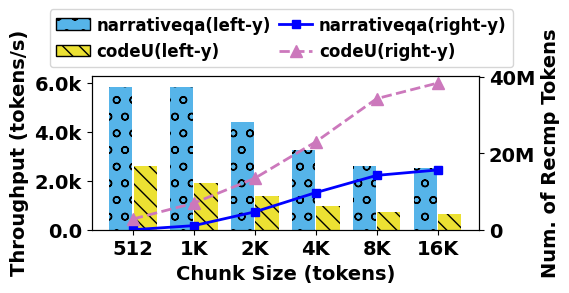

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


37.139619476983704


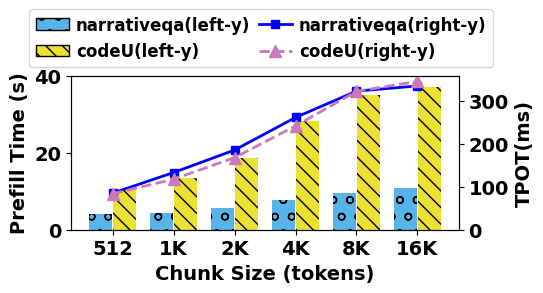

In [70]:
##### Plot the thrpt and recmp tokens vs. ckprefilllen for different dataset using Llama-3.1-8B model
from collections import defaultdict
from pandas import DataFrame
import os

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_v2/venilla_baseline_v0_8_4/"
plots_base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/plots_newest/"

output_dir = f"{plots_base_dir}/motivation/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


model_name = "Llama-3.1-8B"
TP = 1
chunked_prefill_lens = (512, 1024, 2048, 4096, 8192, 16384)
method = "vLLM-default"
# dataset_names = ["narrativeqa", "codeU", "sharegpt"]
dataset_names = ["narrativeqa", "codeU"]

my_df_throughput = defaultdict(lambda: defaultdict(DataFrame))
my_df_latency = defaultdict(lambda: defaultdict(DataFrame))
my_df_recmp = defaultdict(lambda: defaultdict(DataFrame))

# 1) Collect multiple runs for default dataset
for dataset_name in dataset_names:
    my_df_throughput = get_dataset(my_df_throughput, base_dir, dataset_name, model_name, method, "throughput", chunked_prefill_lens, TP)
    my_df_latency = get_dataset(my_df_latency, base_dir, dataset_name, model_name, method, "latency", chunked_prefill_lens, TP)
    my_df_recmp = get_dataset(my_df_recmp, base_dir, dataset_name, model_name, method, "recmp", chunked_prefill_lens, TP)

### Plot throughput and recomputed tokens across different chunk sizes for different datasets
output_file = f"{output_dir}/thrpt_and_recmp_vs_cksize"
strategy = local_strategies_mapping[method]
plot_thrpt_and_recmp_vs_ckprefilllen(chunked_prefill_lens, my_df_throughput[strategy], my_df_recmp[strategy], output_file)

### 2) Plot chunked-prefill length vs. TTFT and TBT latency for different datasets
output_file = f"{output_dir}/ttft_and_tbt_vs_cksize"
plot_latency_vs_ckprefilllen_noqueue(chunked_prefill_lens, my_df_latency[strategy], percentile=None, saved_file=output_file)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


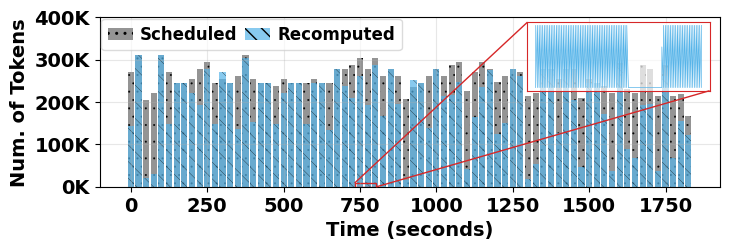

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


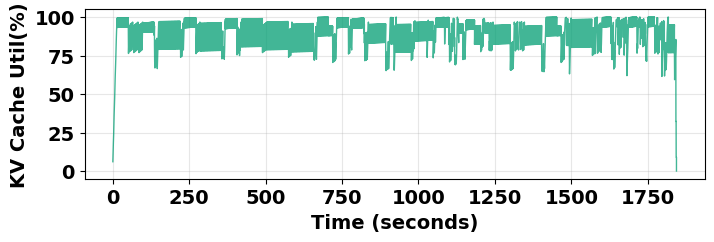

In [71]:
### Plot scheduled and recomputed tokens over time
from collections import defaultdict
from pandas import DataFrame
import os

base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_v2/venilla_baseline_v0_8_4/"
plots_base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/plots_newest/"

output_dir = f"{plots_base_dir}/motivation/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model_name = "Llama-3.1-8B"
dataset_name = "narrativeqa"
chunked_size = 8192
sched_df = get_sched_stats_df(base_dir, "vLLM-default", model_name, dataset_name, chunked_size, TP)

output_file = f"{output_dir}/sched_recomp_tokens_histogram"
# plot_scheduled_recomputed_tokens_histogram(sched_df,time_bin_seconds=25, saved_file=output_file)
plot_scheduled_recomputed_tokens_histogram_1(sched_df,time_bin_seconds=25, saved_file=output_file)

### KV cache utilization over time
output_file = f"{output_dir}/kvcache_util_over_time"
plot_kvcache_util_over_time(sched_df, output_file)

In [72]:
# ### Plot scheduled and recomputed tokens over time
# base_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/eval_results/ipdps25_sched_test/venilla_baseline_v0_8_4/"
# model_name = "Llama-3.1-8B"
# dataset_name = "dureader"
# chunked_size = 8192
# sched_df = get_sched_stats_df(base_dir, "vllm-default", model_name, dataset_name, chunked_size)

# output_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/result_images/motivation/"
# output_file = f"{output_dir}/sched_recomp_tokens_histogram_1.png"
# plot_scheduled_recomputed_tokens_histogram(sched_df,time_bin_seconds=50, saved_file=output_file)


# chunked_size = 16384
# sched_df = get_sched_stats_df(base_dir, "vllm-default", model_name, dataset_name, chunked_size)

# output_dir = "/Users/yejie/Projects/SCS_Lab/IPDPS25_Scheduling/result_images/motivation/"
# output_file = f"{output_dir}/sched_recomp_tokens_histogram_2.png"
# plot_scheduled_recomputed_tokens_histogram(sched_df,time_bin_seconds=50, saved_file=output_file)

